<a href="https://colab.research.google.com/github/NehaMusale11/Machine-Vision/blob/main/Practical_07_MachineV_CM23057.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
!pip install -q ultralytics kagglehub

In [10]:
import os
import glob
import random
import shutil
import kagglehub
from ultralytics import YOLO

In [11]:
path = kagglehub.dataset_download("rohan300557/vehicle-detection")

print("Dataset Path:", path)

Using Colab cache for faster access to the 'vehicle-detection' dataset.
Dataset Path: /kaggle/input/vehicle-detection


In [12]:
for root, dirs, files in os.walk(path):
    print(root)
    print(files[:10])
    print("-"*50)

/kaggle/input/vehicle-detection
[]
--------------------------------------------------
/kaggle/input/vehicle-detection/training_image
['110Truck.txt', 'BUS_141.txt', '65Ambulance.jpg', '43car.txt', 'BUS_19.txt', '30Ambulance.txt', '60Ambulance.txt', '48Truck.jpg', 'BUS_80.jpeg', '12Truck.jpg']
--------------------------------------------------


In [15]:
import glob

classes = set()

label_files = glob.glob(path + "/training_image/*.txt")

for file in label_files:
    try:
        with open(file, "r") as f:
            first_line = f.readline().strip()

            if first_line == "":
                continue

            parts = first_line.split()

            # Only process valid YOLO labels
            if len(parts) == 5 and parts[0].isdigit():
                classes.add(int(parts[0]))

    except Exception:
        continue

print("Classes Found:", sorted(classes))

Classes Found: [0, 1, 2, 3]


In [14]:
import glob

label_file = glob.glob(path + "/training_image/*.txt")[0]

print("Label File:", label_file)

with open(label_file, "r") as f:
    print(f.read())

Label File: /kaggle/input/vehicle-detection/training_image/110Truck.txt
3 0.503082 0.499060 0.847644 0.782581



In [16]:
dataset_path = "/content/vehicle_dataset"

os.makedirs(dataset_path + "/train/images", exist_ok=True)
os.makedirs(dataset_path + "/train/labels", exist_ok=True)

os.makedirs(dataset_path + "/valid/images", exist_ok=True)
os.makedirs(dataset_path + "/valid/labels", exist_ok=True)

print("Folders Created Successfully")

Folders Created Successfully


In [17]:
images = glob.glob(path + "/training_image/*.jpg")

print("Total Images:", len(images))

random.seed(42)
random.shuffle(images)

split = int(len(images) * 0.8)

train_images = images[:split]
valid_images = images[split:]

print("Training Images:", len(train_images))
print("Validation Images:", len(valid_images))

Total Images: 390
Training Images: 312
Validation Images: 78


In [18]:
for img in train_images:

    shutil.copy(img, dataset_path + "/train/images/")

    label = img.replace(".jpg", ".txt")

    if os.path.exists(label):
        shutil.copy(label, dataset_path + "/train/labels/")


for img in valid_images:

    shutil.copy(img, dataset_path + "/valid/images/")

    label = img.replace(".jpg", ".txt")

    if os.path.exists(label):
        shutil.copy(label, dataset_path + "/valid/labels/")

print("Dataset Prepared Successfully")

Dataset Prepared Successfully


In [19]:
yaml_content = """
path: /content/vehicle_dataset

train: train/images
val: valid/images

names:
  0: Ambulance
  1: Bus
  2: Car
  3: Truck
"""

with open("/content/vehicle_dataset/data.yaml", "w") as f:
    f.write(yaml_content)

print("data.yaml Created")

data.yaml Created


In [20]:
with open("/content/vehicle_dataset/data.yaml") as f:
    print(f.read())


path: /content/vehicle_dataset

train: train/images
val: valid/images

names:
  0: Ambulance
  1: Bus
  2: Car
  3: Truck



In [21]:
model = YOLO("yolov8n.pt")

In [23]:
from ultralytics import YOLO

# Load pre-trained YOLOv8 Nano model
model = YOLO("yolov8n.pt")

print("Pre-trained YOLOv8 model loaded successfully!")

Pre-trained YOLOv8 model loaded successfully!


In [24]:
import glob

image_list = glob.glob(path + "/training_image/*.jpg")

print("Total Images:", len(image_list))

results = model.predict(
    source=image_list[:10],   # Detect on first 10 images
    conf=0.4,
    save=True
)

print("Detection Completed!")

Total Images: 390

0: 640x640 1 bus, 1 truck, 217.3ms
1: 640x640 1 truck, 217.3ms
2: 640x640 1 truck, 217.3ms
3: 640x640 1 person, 1 car, 1 motorcycle, 2 trucks, 217.3ms
4: 640x640 5 persons, 1 bus, 3 trucks, 217.3ms
5: 640x640 1 truck, 217.3ms
6: 640x640 4 trucks, 217.3ms
7: 640x640 1 truck, 217.3ms
8: 640x640 1 truck, 217.3ms
9: 640x640 4 cars, 217.3ms
Speed: 3.7ms preprocess, 217.3ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict
Detection Completed!


Detected Images: 10


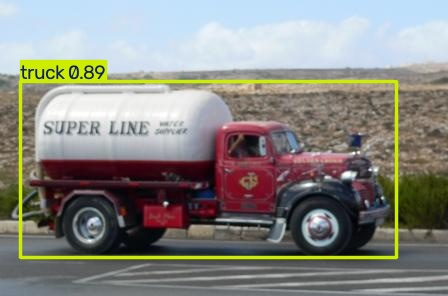

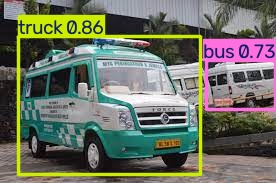

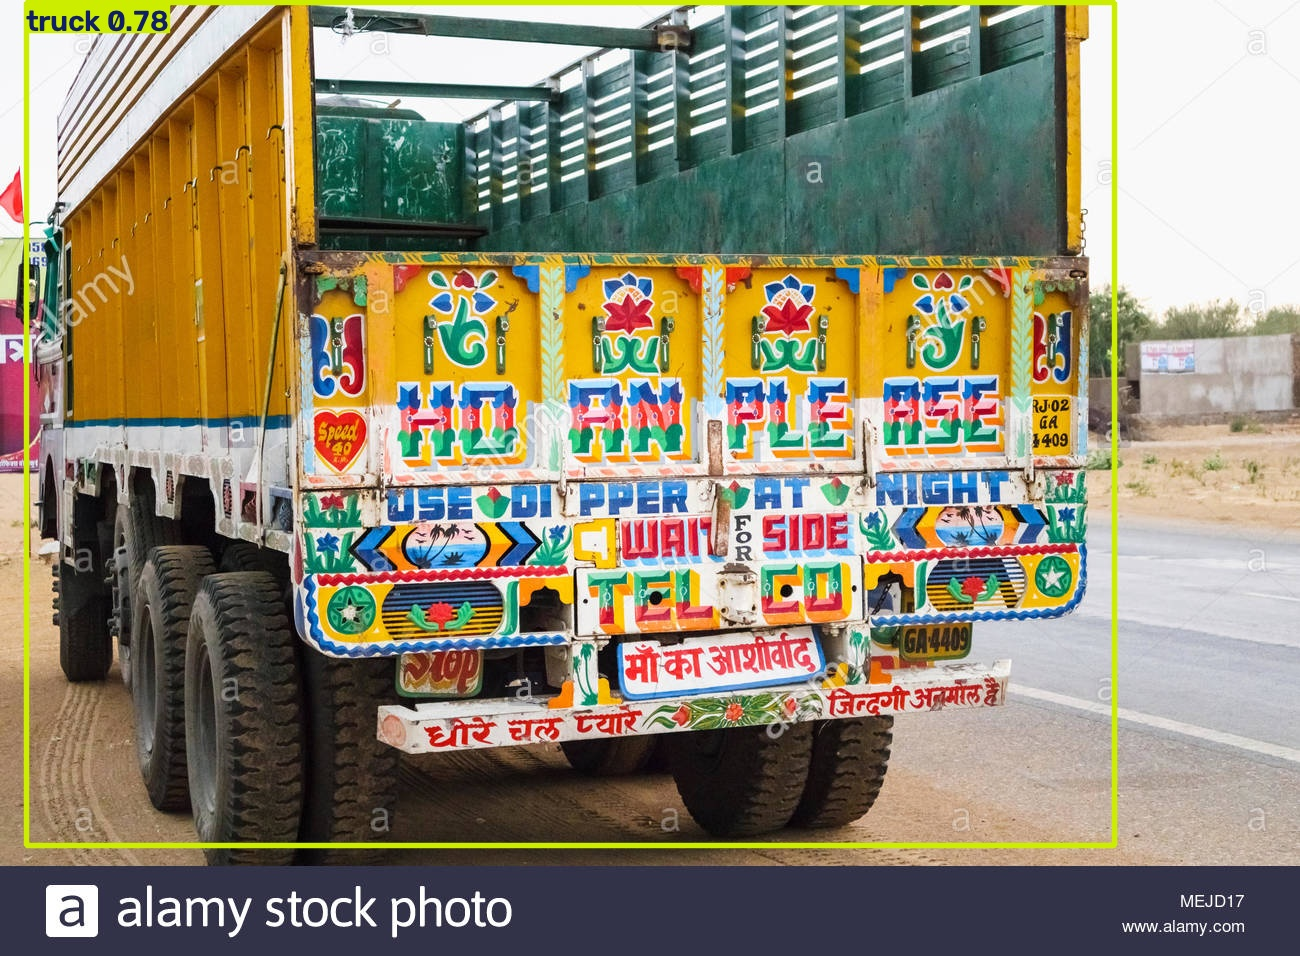

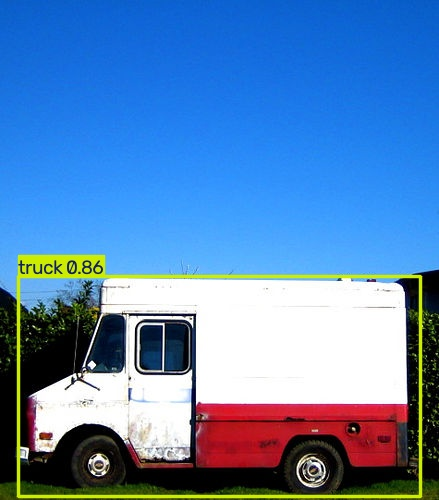

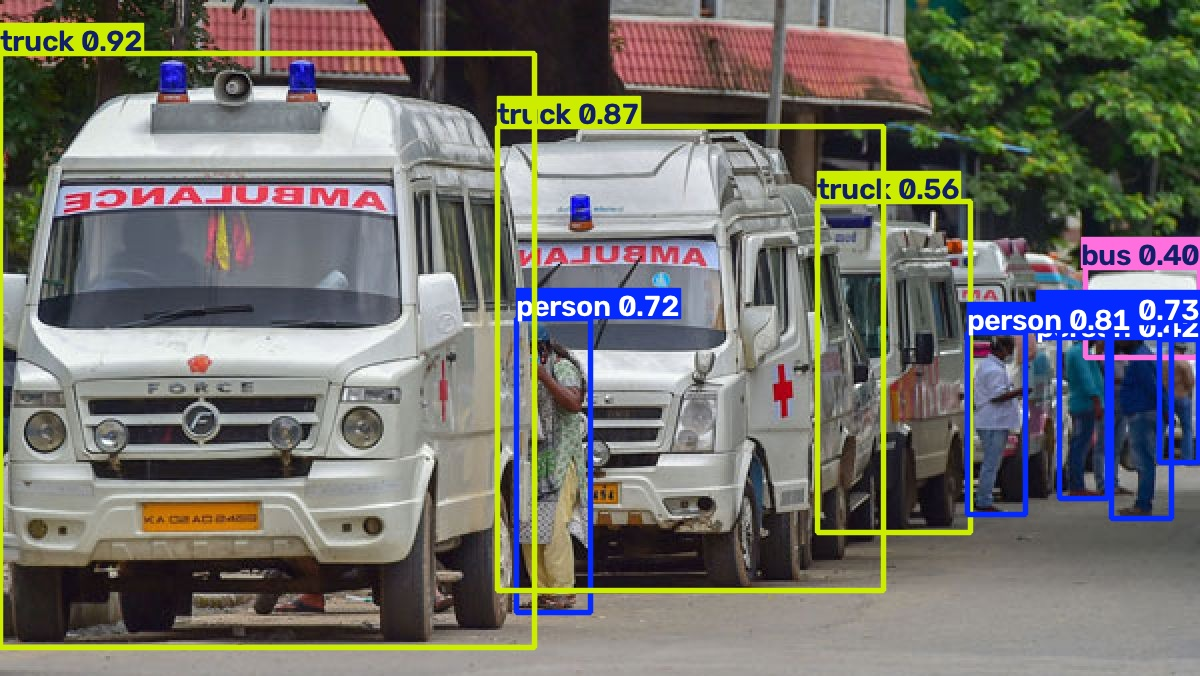

In [25]:
from IPython.display import Image, display
import glob

result_images = glob.glob("runs/detect/predict/*.jpg")

print("Detected Images:", len(result_images))

for img in result_images[:5]:
    display(Image(filename=img))

In [26]:
from google.colab import files

uploaded = files.upload()

video_path = list(uploaded.keys())[0]
print("Uploaded Video:", video_path)

Saving 13926765_3840_2160_24fps.mp4 to 13926765_3840_2160_24fps.mp4
Uploaded Video: 13926765_3840_2160_24fps.mp4


In [1]:
from ultralytics import YOLO
import os

# Re-initialize the model
model = YOLO('yolov8n.pt')

# Retrieve the video path
try:
    video_path
except NameError:
    videos = [f for f in os.listdir('.') if f.endswith('.mp4')]
    video_path = videos[0] if videos else None

if video_path:
    print(f'Tracking video: {video_path}')
    # Using stream=True to prevent memory issues
    results = model.track(
        source=video_path,
        tracker='bytetrack.yaml',
        persist=True,
        save=True,
        conf=0.4,
        stream=True
    )

    # Iterate through the generator to execute the tracking
    for r in results:
        pass

    print('Vehicle Tracking Completed!')
    print(f'Results saved to: runs/detect/track/')
else:
    print('Error: No video file found. Please upload a video first.')

Tracking video: 13926765_3840_2160_24fps.mp4

video 1/1 (frame 1/681) /content/13926765_3840_2160_24fps.mp4: 384x640 3 persons, 4 cars, 1 bus, 1 truck, 416.8ms
video 1/1 (frame 2/681) /content/13926765_3840_2160_24fps.mp4: 384x640 3 persons, 3 cars, 1 bus, 1 truck, 235.5ms
video 1/1 (frame 3/681) /content/13926765_3840_2160_24fps.mp4: 384x640 2 persons, 4 cars, 1 bus, 1 truck, 265.2ms
video 1/1 (frame 4/681) /content/13926765_3840_2160_24fps.mp4: 384x640 2 persons, 3 cars, 1 bus, 1 truck, 157.0ms
video 1/1 (frame 5/681) /content/13926765_3840_2160_24fps.mp4: 384x640 3 persons, 3 cars, 1 bus, 1 truck, 151.8ms
video 1/1 (frame 6/681) /content/13926765_3840_2160_24fps.mp4: 384x640 3 persons, 3 cars, 1 bus, 1 truck, 144.5ms
video 1/1 (frame 7/681) /content/13926765_3840_2160_24fps.mp4: 384x640 4 persons, 2 cars, 1 bus, 1 truck, 165.7ms
video 1/1 (frame 8/681) /content/13926765_3840_2160_24fps.mp4: 384x640 3 persons, 2 cars, 1 bus, 2 trucks, 155.1ms
video 1/1 (frame 9/681) /content/13926765

Frame 0:
Original / Background Subtraction


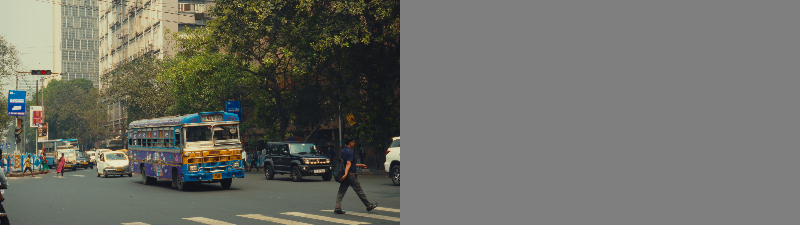

Frame 30:
Original / Background Subtraction


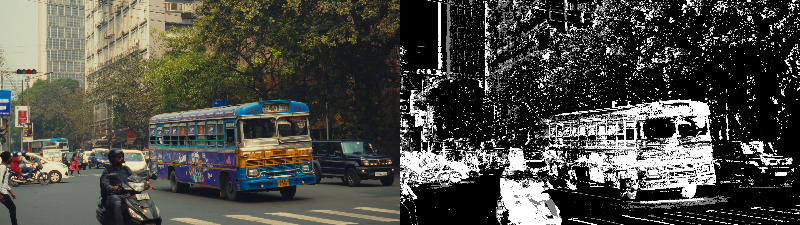

Frame 60:
Original / Background Subtraction


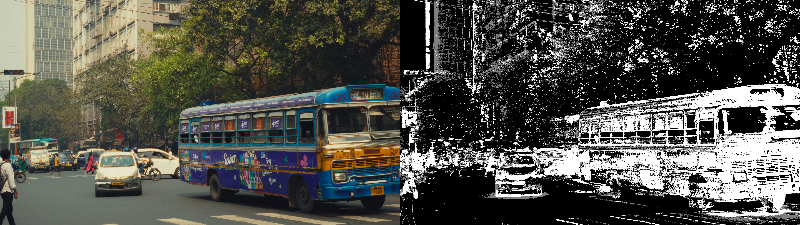

Frame 90:
Original / Background Subtraction


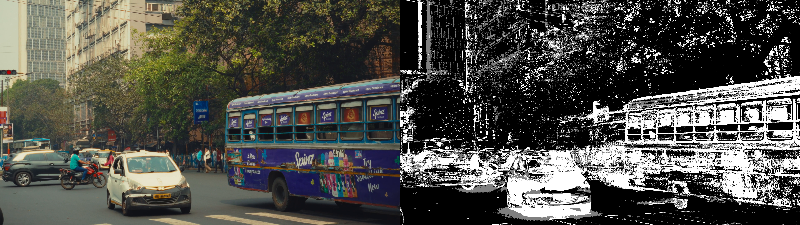

Processing finished.


In [5]:
import cv2
from google.colab.patches import cv2_imshow

cap = cv2.VideoCapture(video_path)
backSub = cv2.createBackgroundSubtractorMOG2()

frame_count = 0
while True:
    ret, frame = cap.read()
    if not ret or frame_count > 100: # Limit frames for display
        break

    fgMask = backSub.apply(frame)

    # Display every 30th frame to show progress without flooding the output
    if frame_count % 30 == 0:
        print(f"Frame {frame_count}:")
        # Resize for better visibility in the notebook
        small_frame = cv2.resize(frame, (400, 225))
        small_mask = cv2.resize(fgMask, (400, 225))

        print("Original / Background Subtraction")
        combined = cv2.hconcat([small_frame, cv2.cvtColor(small_mask, cv2.COLOR_GRAY2BGR)])
        cv2_imshow(combined)

    frame_count += 1

cap.release()
print("Processing finished.")

Motion Frame 0:


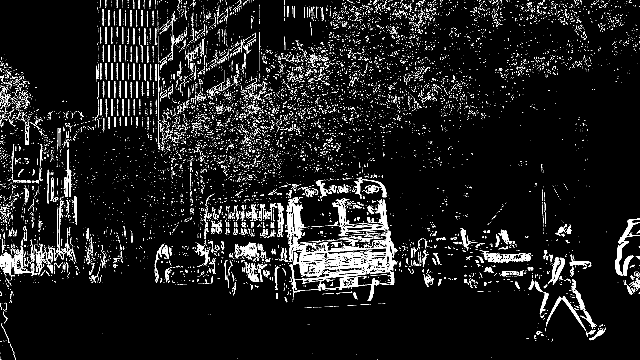

Motion Frame 30:


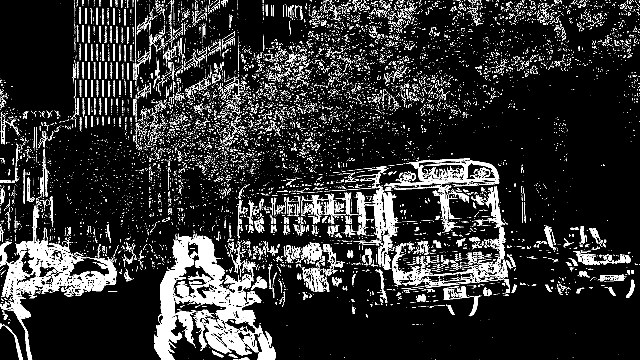

Motion Frame 60:


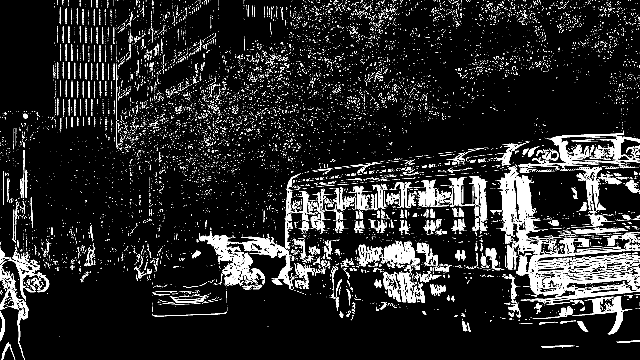

Motion Frame 90:


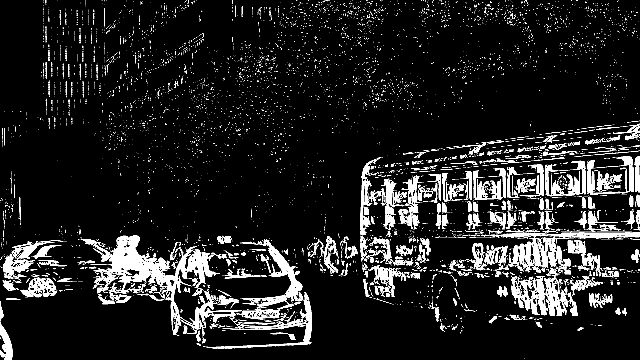

Motion Frame 120:


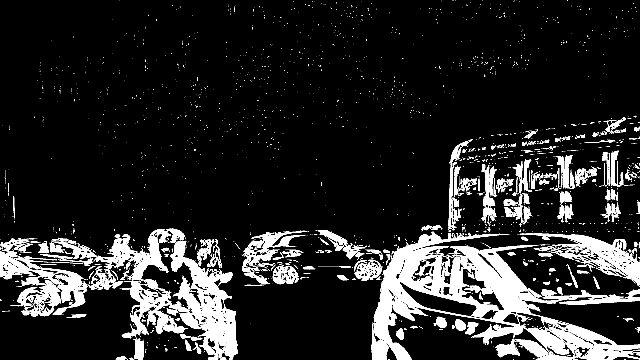

Motion detection processing finished.


In [7]:
import cv2
from google.colab.patches import cv2_imshow

cap = cv2.VideoCapture(video_path)

ret, frame1 = cap.read()
ret, frame2 = cap.read()

frame_count = 0
while cap.isOpened():
    diff = cv2.absdiff(frame1, frame2)
    gray = cv2.cvtColor(diff, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (5,5), 0)
    _, thresh = cv2.threshold(blur, 20, 255, cv2.THRESH_BINARY)

    # Display every 30th frame and limit to the first 120 frames
    if frame_count % 30 == 0:
        print(f"Motion Frame {frame_count}:")
        # Resize for better display
        display_thresh = cv2.resize(thresh, (640, 360))
        cv2_imshow(display_thresh)

    frame1 = frame2
    ret, frame2 = cap.read()
    frame_count += 1

    if not ret or frame_count > 120:
        break

cap.release()
print("Motion detection processing finished.")

Optical Flow at Frame 0:


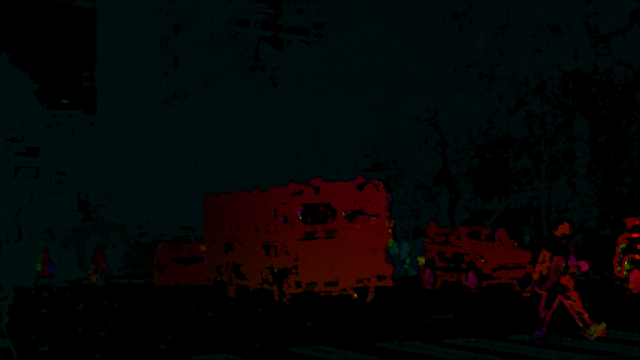

Optical Flow at Frame 30:


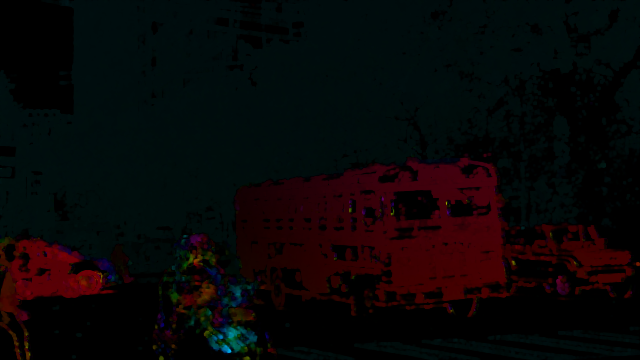

Optical Flow at Frame 60:


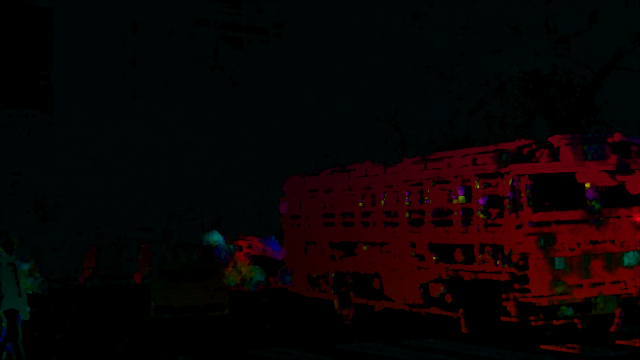

Optical Flow at Frame 90:


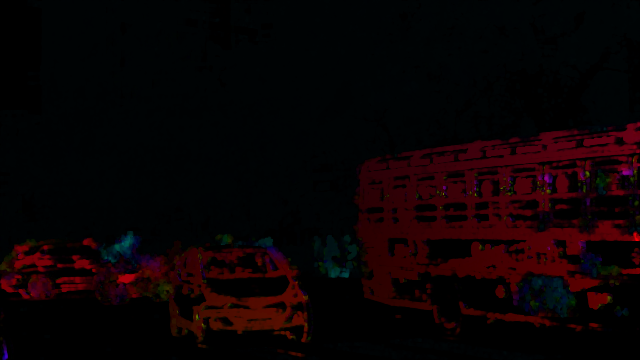

Optical Flow processing finished.


In [9]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

cap = cv2.VideoCapture(video_path)

ret, frame1 = cap.read()
prev_gray = cv2.cvtColor(frame1, cv2.COLOR_BGR2GRAY)

frame_count = 0
while True:
    ret, frame2 = cap.read()
    if not ret or frame_count > 90:
        break

    gray = cv2.cvtColor(frame2, cv2.COLOR_BGR2GRAY)

    # Calculate Farneback Optical Flow
    flow = cv2.calcOpticalFlowFarneback(
        prev_gray, gray, None, 0.5, 3, 15, 3, 5, 1.2, 0
    )

    # Display every 30th frame
    if frame_count % 30 == 0:
        mag, ang = cv2.cartToPolar(flow[...,0], flow[...,1])
        hsv = np.zeros_like(frame2)
        hsv[...,1] = 255
        hsv[...,0] = ang * 180 / np.pi / 2
        hsv[...,2] = cv2.normalize(mag, None, 0, 255, cv2.NORM_MINMAX)
        rgb = cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR)

        print(f"Optical Flow at Frame {frame_count}:")
        # Resize for notebook visibility
        display_flow = cv2.resize(rgb, (640, 360))
        cv2_imshow(display_flow)

    prev_gray = gray
    frame_count += 1

cap.release()
print("Optical Flow processing finished.")